# Data Collection & Indicator calucation

In [325]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [326]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/aapl_Training_Data.csv")
data = data.set_index("Date")

training_data = data.loc[:, ~data.columns.isin(["strength target", "target", "regression target"])].copy()
target= data.loc[:, ["strength target"]].copy()

display(data.head())
display(training_data.shape, target.shape)

,open,high,low,close,volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,target,strength target,regression target
Date,,,,,,,,,,,,,,,,,,,,,
2010-07-16,7.510540,7.662915,7.465760,7.609118,1039858400,4.723735e+08,1039858400,0.454267,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,7.609118,0.000000,0.000000,0.000000,0,2,0
2010-07-19,7.380705,7.509938,7.200982,7.509938,1024478000,1.496852e+09,15380400,0.725101,-1.016074e+08,-0.006299,...,-0.118119,-0.023624,-0.094495,7.565160,-1.303432,-1.312001,-1.303432,0,2,0
2010-07-20,7.570348,7.600703,7.213305,7.300162,1074950800,9.039194e+08,-1059570400,0.287938,-1.193063e+08,0.001858,...,0.177847,0.016670,0.161177,7.444276,-2.793320,-2.833075,-4.060343,1,2,1
2010-07-21,7.640975,7.968866,7.633762,7.967062,1185671200,2.076830e+09,126100800,0.480196,1.069816e+07,0.011144,...,1.242836,0.261904,0.980933,7.681051,9.135420,8.741931,4.704148,0,2,0
2010-07-22,7.784633,7.814086,7.673131,7.744360,645318800,2.083711e+09,-519218000,0.419234,-1.136071e+07,-0.001260,...,-2.092536,-0.208984,-1.883552,7.709075,-2.795287,-2.835099,1.777366,1,2,1


(3772, 91)

(3772, 1)

## Data Preparation:

In [327]:
from sklearn.model_selection import TimeSeriesSplit

def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"
    
    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
    return train_df, test_df

In [328]:
from sklearn.model_selection import train_test_split

def define_rule_based_indicators_list(X):
    rule_based_indicators =[]
    for col in X.columns:
        if len(X[col].unique()) <= 2:
            rule_based_indicators.append(col)
    
    return rule_based_indicators

print(define_rule_based_indicators_list(training_data))

#X, Valid_set, y, Valid_result = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]

np.unique(y, return_counts=True), np.unique(Valid_result, return_counts=True)

['volatility_bbhi', 'volatility_bbli', 'volatility_kchi', 'volatility_kcli', 'trend_psar_up_indicator', 'trend_psar_down_indicator']


((array([0, 1, 2]), array([2310,  404,  303])),
 (array([1, 2]), array([354, 401])))

In [329]:
import numpy as np

def find_trim_index_to_include_classes(y, required_classes=(0, 1, 2), window=600):
    """
    Find the starting index where a rolling window of size `window` contains all required classes.

    Parameters:
        y (array-like): The target vector (1D NumPy array or Pandas Series).
        required_classes (tuple): The set of classes that must be present.
        window (int): Window size to check.

    Returns:
        int: Starting index where all required classes appear in the window.
    """
    y = np.array(y)  # Ensure it's a NumPy array
    n = len(y)
    
    for start in range(n - window + 1):
        window_classes = set(y[start : start + window])
        if set(required_classes).issubset(window_classes):
            print(f"✅ Found all classes starting at index {start}.")
            return start

    raise ValueError("❌ Could not find a window with all required classes.")

start_index = find_trim_index_to_include_classes(y.values.ravel(), required_classes=(0, 1, 2), window=600)
df_trimmed = data.iloc[start_index:].reset_index(drop=True)

print(np.unique(df_trimmed["strength target"], return_counts=True))

np.unique(Valid_result, return_counts=True)

✅ Found all classes starting at index 1823.
(array([0, 1, 2]), array([526, 739, 684]))


(array([1, 2]), array([354, 401]))

## Data Plots:

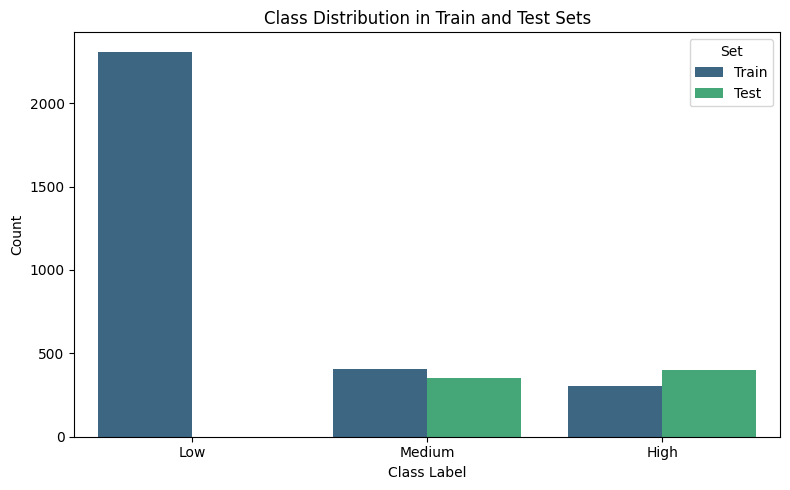

In [330]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(y_train, y_test, labels=None):
    # Combine both into a dataframe for seaborn
    df = pd.DataFrame({
        'Label': pd.concat([y_train.squeeze(), y_test.squeeze()], axis=0),
        'Set': ['Train'] * len(y_train) + ['Test'] * len(y_test)
    })

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='Label', hue='Set', palette='viridis')
    
    plt.title('Class Distribution in Train and Test Sets')
    plt.xlabel('Class Label')
    plt.ylabel('Count')
    
    if labels:
        plt.xticks(ticks=range(len(labels)), labels=labels)
    
    plt.tight_layout()
    plt.show()
    
plot_class_distribution(y_train=y.copy(), y_test=Valid_result.copy(), labels=["Low", "Medium", "High"])

Text(0, 0.5, 'Price')

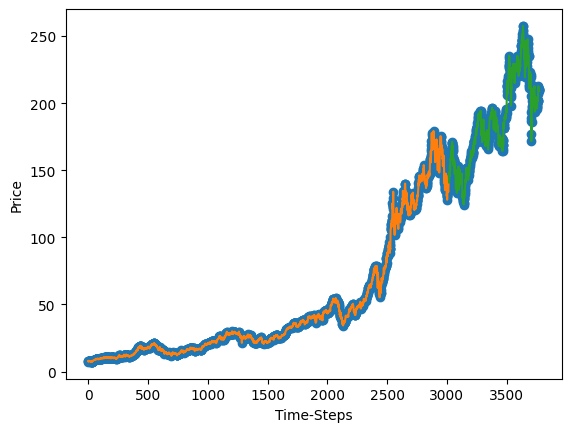

In [331]:
from matplotlib import pyplot as plt

df = training_data.reset_index(drop=True)
price = df.loc[:, 'close']
plt.plot(price.index, price.values, 'o')

for df in [X, Valid_set]:
    price = df.loc[:, 'close']
    plt.plot(price.index, price.values)
    
plt.xlabel("Time-Steps")
plt.ylabel("Price")

## Scoring for Tuning and Optimization:

In [332]:
#scoring = "accuracy"
scoring = "f1"

### Fold CV fucntion:

In [333]:
def walk_forward_cv(X, train_size=600, test_size=30, step_size=100, n_splits=5):
    """
    Generator for walk-forward CV splits with optional number of splits.

    Parameters:
    - X: input data
    - train_size: number of samples in the training set
    - test_size: number of samples in the test set
    - step_size: how much to move the window forward
    - n_splits: (optional) maximum number of splits to generate
    """
    n_samples = len(X)
    split_count = 0

    for start in range(0, n_samples - train_size - test_size + 1, step_size):
        if n_splits is not None and split_count >= n_splits:
            break
        
        train_idx = list(range(start, start + train_size))
        test_idx = list(range(start + train_size, start + train_size + test_size))
        
        yield train_idx, test_idx
        split_count += 1

def purged_kfold_split(X, n_splits=15, lookahead=5, embargo=0):

    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx
        
def purged_kfold_split_with_class_requirements(y, n_splits=10, lookahead=5, embargo=0, required_train_classes=(0, 1, 2), min_test_classes=2):
    """
    Purged K-Fold with lookahead and embargo, ensuring:
    - train set contains all required_train_classes
    - test set contains at least `min_test_classes` unique values
    """
    y = np.array(y)
    n_samples = len(y)
    fold_size = n_samples // n_splits

    eval = 0
    valid_folds = []
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Purge overlap before test
        train_end_1 = max(0, test_start - lookahead)
        # Embargo after test
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        train_idx = list(range(0, train_end_1)) + list(range(embargo_end, n_samples))
        test_idx = list(range(test_start, test_end))

        y_train = y[train_idx]
        y_test = y[test_idx]

        train_classes = set(y_train)
        test_classes = set(y_test)

        if not set(required_train_classes).issubset(train_classes):
            print(f"⛔ Skipping fold {i+1}: missing classes in train → {train_classes}")
            continue
        if len(test_classes) < min_test_classes:
            print(f"⚠️  Skipping fold {i+1}: too few classes in test → {test_classes}")
            continue

        valid_folds.append((train_idx, test_idx))
        
        eval += 1
        if eval == 5:
            break


    return valid_folds


### SMOTE model setting:

In [334]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',  # or float/dict/‘auto’
    random_state=42,
    k_neighbors=3,                     # neighbors used to generate synthetic samples
)

### Model Evaluation:

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

def Evaluation_for_Testing_part(model, X=X.copy(), y=y.copy(), Valid_set=Valid_set, Valid_result=Valid_result, threshold=False):
    X_train_1 = X.copy()
    y_train_1 = y.copy()
    X_test_1 = Valid_set.copy()
    y_test_1 = Valid_result.copy()
    if threshold == False:
        pass
    else:
        print(f"The Best Threshold: {threshold}")
    f1_array_micro = []
    f1_array_macro = []
    valid_folds = 0
    
    start_index = find_trim_index_to_include_classes(y_train_1.copy().values.ravel(), required_classes=(0, 1, 2), window=600)
    X_subtrain_1, y_subtrain_1 = X_train_1.iloc[start_index:], y_train_1.iloc[start_index:]
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split_with_class_requirements(y_subtrain_1.copy().values.ravel())):
        # Split data
        X_train, y_train = X_subtrain_1.iloc[train_idx].copy(), y_subtrain_1.iloc[train_idx].copy()
        X_test, y_test = X_subtrain_1.iloc[test_idx].copy(), y_subtrain_1.iloc[test_idx].copy()
        
        unit = 3
        if len(np.unique(y_train)) < unit:
            print(f"Skipping fold {fold_idx+1}: insufficient classes -> {np.unique(y_train)}")
            continue
        if len(np.unique(y_test)) < unit-1:
            print(f"Skipping fold {fold_idx+1}: insufficient classes -> {np.unique(y_test)}")
            continue
            

        # Feature selection
        X_train = Ensemble_Feature_Selection(model=model, X=X_train, y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]

        # === SMOTE to handle class imbalance in training set ===
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        # Calibrated model training
        '''
        calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)
        calibrated_model.fit(X_train_res, y_train_res)
        '''
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_res)
        model.fit(X_train_res, y_train_res,
            sample_weight=sample_weights,
            eval_set=[(X_test, y_test)],
            verbose=100
        )

        
        if threshold == False:
            '''
            y_pred = calibrated_model.predict(X_test)
            '''
            y_pred = model.predict(X_test)
        else:
            y_proba = model.predict_proba(X_test)
            '''
            y_proba = calibrated_model.predict_proba(X_test) # Probabilities
            '''
            y_pred = predict_with_thresholds_per_class(y_proba, threshold)
        
        # Evaluation
        print()
        print(f"Fold {fold_idx + 1}")
        print(f"Train: {np.unique(y_train_res, return_counts=True)}")
        print(f"Test: {np.unique(y_test, return_counts=True)}")
        print(f"Prediction: {np.unique(y_pred, return_counts=True)}, micro: {f1_score(y_true=y_test, y_pred=y_pred, average='micro'):.2f}, macro: {f1_score(y_true=y_test, y_pred=y_pred, average='macro'):.2f}")

        # Append scores
        f1_array_micro.append(f1_score(y_true=y_test, y_pred=y_pred, average='micro'))
        f1_array_macro.append(f1_score(y_true=y_test, y_pred=y_pred, average='macro'))
        
        valid_folds += 1
        if valid_folds >= 5:
            break

    X_train_1 = Ensemble_Feature_Selection(model=model, X=X_train_1, y=y_train_1)
    X_test_1 = X_test_1.loc[:, X_train_1.columns.tolist()]
    
    #X_train_res, y_train_res = smote.fit_resample(X_train_1, y_train_1)
    X_train_res, y_train_res = X_train_1, y_train_1
    '''
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)
    calibrated_model.fit(X_train_res, y_train_res)
    '''
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_res)
    model.fit(X_train_res, y_train_res,
            sample_weight=sample_weights,
            eval_set=[(X_test_1, y_test_1)],
            verbose=100
        )

    if threshold == False:
        '''
        y_pred_1 = calibrated_model.predict(X_test_1)
        '''
        y_pred_1 = model.predict(X_test_1)
    else:
        '''
        y_proba_1 = calibrated_model.predict_proba(X_test_1) # Probabilities
        '''
        y_proba_1 = model.predict_proba(X_test_1) # Probabilities
        y_pred_1 = predict_with_thresholds_per_class(y_proba_1, threshold)
    
    print()
    print(f"Train: {np.unique(y_train_res, return_counts=True)}")
    print(f"Test: {np.unique(y_test_1, return_counts=True)}")
    print(f"Prediction: {np.unique(y_pred_1, return_counts=True)}")
    print(len(y_pred_1), len(y_test_1))

    # Optional: print average results
    print()
    print(f"Micro: train_cv-{np.mean(f1_array_micro)}, test-{f1_score(y_true=y_test_1, y_pred=y_pred_1, average='micro')}")
    print(f"Macro: train_cv-{np.mean(f1_array_macro)} test-{f1_score(y_true=y_test_1, y_pred=y_pred_1, average='macro')}")
    print(classification_report(y_test_1, y_pred_1))

def evaluation_score_test_2(model, X_train_1, y_train_1, threshold=False):
    f1_array_micro = []
    f1_array_macro = []
    
    valid_folds = 0
    start_index = find_trim_index_to_include_classes(y_train_1.copy().values.ravel(), required_classes=(0, 1, 2), window=600)
    X_subtrain_1, y_subtrain_1 = X_train_1.iloc[start_index:], y_train_1.iloc[start_index:]
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split_with_class_requirements(y_subtrain_1.copy().values.ravel())):
        # Split data
        X_train, y_train = X_subtrain_1.iloc[train_idx].copy(), y_subtrain_1.iloc[train_idx].copy()
        X_test, y_test = X_subtrain_1.iloc[test_idx].copy(), y_subtrain_1.iloc[test_idx].copy()

        unit = 3
        if len(np.unique(y_train)) < unit or len(np.unique(y_test)) < unit:
            #print(f"Skipping fold {fold_idx+1}: insufficient classes")
            continue

        # Feature selection
        X_train = Ensemble_Feature_Selection(model=model, X=X_train, y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]

        # === SMOTE to handle class imbalance in training set ===
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_res)
        model.fit(X_train_res, y_train_res,
            sample_weight=sample_weights,
            eval_set=[(X_test, y_test)],
            verbose=100
        )

        if threshold == False:
            '''
            # Calibrated model training
            calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)
            calibrated_model.fit(X_train_res, y_train_res)
            y_pred = calibrated_model.predict(X_test)
            '''
            
            y_pred = model.predict(X_test)
        else:
            y_proba = model.predict_proba(X_test)
            y_pred = predict_with_thresholds_per_class(y_proba, threshold)

        # Append scores
        f1_array_micro.append(f1_score(y_true=y_test, y_pred=y_pred, average='micro'))
        f1_array_macro.append(f1_score(y_true=y_test, y_pred=y_pred, average='macro'))
        
        valid_folds += 1
        if valid_folds >= 5:
            break

    #return np.mean([np.mean(f1_array_macro), np.mean(f1_array_micro)])
    #return np.mean(f1_array_micro)
    return np.mean(f1_array_macro)

def evaluation_score_test(base_model, X_train_1, y_train_1):
    cv = purged_kfold_split(X_train_1.copy())
    scores = cross_val_score(estimator=base_model, X=X_train_1.copy(), y=y_train_1.copy(), cv=cv, scoring=scoring, n_jobs=-1)
    return np.mean(scores) 

# Feature Filter functions:

In [336]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from boruta import BorutaPy
import shap
from scipy.stats import wilcoxon

# ---------------------------
# Feature Selection Functions
# ---------------------------

def low_variance_filter(X, threshold=1e-4):
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X)
    return X.columns[selector.get_support()]

def mi_filter(X, y, threshold=1e-4):
    mi = mutual_info_classif(X, y)
    selected = X.columns[mi > threshold]
    return selected

def feature_importances(X, y, model):
    model.fit(X, y)
    return X.columns[model.feature_importances_ > 0]

def correlation_filter(X, threshold=0.95):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return X.drop(columns=to_drop).columns

def f_test_pvalue_filter(X, y, alpha=0.05):
    selector = SelectKBest(score_func=f_classif, k='all')
    selector.fit(X, y)
    return X.columns[selector.pvalues_ < alpha]

def boruta_filter(X, y, model):
    feat_selector = BorutaPy(model, n_estimators='auto', verbose=0, random_state=42)
    feat_selector.fit(X.values, y.values)
    return X.columns[feat_selector.support_]

def rfe_filter(X, y, model, n_features_to_select=10):
    selector = RFE(estimator=model, n_features_to_select=n_features_to_select, step=1)
    selector.fit(X, y)
    return X.columns[selector.support_]

def shap_filter(X, y, model, threshold=0.01):
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    mean_abs_shap = np.abs(shap_values).mean(axis=0).mean(axis=1)

    #print(mean_abs_shap, X.columns.to_numpy())
    selected_features = X.columns.to_numpy()[mean_abs_shap > threshold]
    return selected_features

def permutation_importance_filter(X, y, model, threshold=0.001):
    model.fit(X, y)
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
    return X.columns[result.importances_mean > threshold]

def chi2_filter(X, y, threshold=0.05):
    X_nonneg = X.copy()
    X_nonneg[X_nonneg < 0] = 0
    chi_scores, p_values = chi2(X_nonneg, y)
    return X.columns[p_values < threshold]

def l1_filter(X, y, C=0.01):
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C)
    model.fit(X, y)
    return X.columns[model.coef_[0] != 0]

def vif_filter(X, threshold=10):
    X = X.copy()
    while True:
        vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        max_vif = max(vif)
        if max_vif > threshold:
            max_index = vif.index(max_vif)
            X.drop(columns=[X.columns[max_index]], inplace=True)
        else:
            break
    return X.columns


# ---------------------------
# Feature Scaling Functions:
# ---------------------------
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

def scale_minmax(data):
    """
    Scales features to range [0, 1] using MinMaxScaler.
    Useful for Chi2 and distance-based methods.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_standard(data):
    """
    Scales features to zero mean and unit variance using StandardScaler.
    Useful for linear models (L1), permutation, and statistical tests like F-test.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_none(X):
    return X.copy()


# ---------------------------
# Safe Wilcoxon Test
# ---------------------------

def safe_wilcoxon_test(before, after):
    diff = np.array(after) - np.array(before)
    if np.all(diff == 0):
        return None, 1.0
    return wilcoxon(before, after)


# ---------------------------
# Evaluation Pipeline
# ---------------------------

def evaluate_feature_filters(X, y, base_model):

    X_none = scale_none(X.copy())
    X_minmax = scale_minmax(X.copy())
    X_standard = scale_standard(X.copy())

    methods = {
        'Low Variance': low_variance_filter(X_none),
        'Mutual Info': mi_filter(X_none, y),
        'Correlation Filter': correlation_filter(X_none),
        'F-test': f_test_pvalue_filter(X_standard, y),
        'Permutation': permutation_importance_filter(X_standard, y, base_model),
        'Chi2': chi2_filter(X_minmax, y),
        'L1': l1_filter(X_standard, y),
        'VIF': vif_filter(X_none),
    }

    accepted = {}
    rejected = {}
    base_scores = evaluation_score_test(base_model=base_model, X_train_1=X.copy(), y_train_1=y.copy())
    
    for name, selected in methods.items():
        if len(selected) > 0:
            X_selected = X.loc[:, selected]
        else:
            continue
        selected_scores = evaluation_score_test(base_model=base_model, X_train_1=X_selected, y_train_1=y.copy())
        stat, p = safe_wilcoxon_test(base_scores, selected_scores)
        '''
        if p >= 0.05:
        '''
        if p < 0.05 or np.mean(selected_scores) > np.mean(base_scores):
            accepted[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
        else:
            rejected[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
    
    return accepted, rejected


# Combine all accepted feature sets using three strategies
import torch
from itertools import combinations

def create_collaboration_sets_combination_torch(accepted, feature_names):
    if not accepted:
        return {}

    method_names = list(accepted.keys())
    n_methods = len(method_names)
    n_features = len(feature_names)

    # Map feature names to index
    feature_idx_map = {name: i for i, name in enumerate(feature_names)}

    # Create binary tensor: shape (n_methods, n_features)
    method_tensor = torch.zeros((n_methods, n_features), dtype=torch.bool)

    for i, method in enumerate(method_names):
        selected_feats = accepted[method]['features']
        indices = [feature_idx_map[f] for f in selected_feats if f in feature_idx_map]
        method_tensor[i, indices] = 1  # mark selected features

    # Generate intersection sets from combinations (unordered)
    result_sets = {}
    for r in range(1, n_methods + 1):
        for combo in combinations(range(n_methods), r):
            combo_name = " ∩ ".join([method_names[i] for i in combo])
            intersected = method_tensor[combo[0]].clone()
            for idx in combo[1:]:
                intersected &= method_tensor[idx]
            if intersected.sum() > 0:
                selected_feature_names = [feature_names[i] for i in torch.where(intersected)[0]]
                result_sets[combo_name] = selected_feature_names

    return result_sets

## --> Feature Selection Ensemble function:

In [337]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

def Ensemble_Feature_Selection(X, model, y):
    
    X = X.loc[:, selected_feature_set]
    #X = scale_standard(X.copy())
    return X

# The Basic Model:

## model identift:

In [338]:
from xgboost import XGBClassifier

base_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',  # You can still calculate F1 manually later
    use_label_encoder=False,
    tree_method='auto',  # Change to 'auto' if no GPU
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=1000,       # With early stopping
    random_state=42
)

## feature selection:

In [339]:
X_train_1 = X.copy()
y_train_1 = y.copy()

accepted, rejected = evaluate_feature_filters(X=X_train_1, y=y_train_1, base_model=base_model)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:22:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:22:47] WARN

In [340]:
print(f"accepted set:", accepted.keys())
print(f"rejected set:", rejected.keys())

accepted set: dict_keys([])
rejected set: dict_keys(['Low Variance', 'Mutual Info', 'Correlation Filter', 'F-test', 'Permutation', 'Chi2', 'L1', 'VIF'])


In [341]:
# Create collaboration sets
combined_sets = create_collaboration_sets_combination_torch(accepted={**accepted, **rejected}, feature_names=X_train_1.columns.tolist())
for key, item in combined_sets.items():
    print(f"{key}: {len(item)}")
'''
# Create collaboration sets
if combined_sets == {}:
    combined_sets = create_collaboration_sets_combination_torch(accepted=rejected, feature_names=X_train_1.columns.tolist())
    for key, item in combined_sets.items():
        print(f"{key}: {len(item)}")
'''

Low Variance: 91
Mutual Info: 82
Correlation Filter: 57
F-test: 82
Permutation: 4
Chi2: 43
L1: 5
VIF: 29
Low Variance ∩ Mutual Info: 82
Low Variance ∩ Correlation Filter: 57
Low Variance ∩ F-test: 82
Low Variance ∩ Permutation: 4
Low Variance ∩ Chi2: 43
Low Variance ∩ L1: 5
Low Variance ∩ VIF: 29
Mutual Info ∩ Correlation Filter: 49
Mutual Info ∩ F-test: 77
Mutual Info ∩ Permutation: 4
Mutual Info ∩ Chi2: 42
Mutual Info ∩ L1: 5
Mutual Info ∩ VIF: 24
Correlation Filter ∩ F-test: 49
Correlation Filter ∩ Permutation: 3
Correlation Filter ∩ Chi2: 16
Correlation Filter ∩ L1: 4
Correlation Filter ∩ VIF: 26
F-test ∩ Permutation: 4
F-test ∩ Chi2: 43
F-test ∩ L1: 5
F-test ∩ VIF: 21
Permutation ∩ Chi2: 4
Permutation ∩ L1: 2
Permutation ∩ VIF: 1
Chi2 ∩ L1: 3
Chi2 ∩ VIF: 7
L1 ∩ VIF: 1
Low Variance ∩ Mutual Info ∩ Correlation Filter: 49
Low Variance ∩ Mutual Info ∩ F-test: 77
Low Variance ∩ Mutual Info ∩ Permutation: 4
Low Variance ∩ Mutual Info ∩ Chi2: 42
Low Variance ∩ Mutual Info ∩ L1: 5
Low Var

'\n# Create collaboration sets\nif combined_sets == {}:\n    combined_sets = create_collaboration_sets_combination_torch(accepted=rejected, feature_names=X_train_1.columns.tolist())\n    for key, item in combined_sets.items():\n        print(f"{key}: {len(item)}")\n'

In [342]:
feature_set = {}
for idx, features in combined_sets.items():
    value_to_find = features
    if value_to_find not in feature_set.values() or feature_set == {}:
        matching_keys = [k for k, v in combined_sets.items() if v == value_to_find]
        feature_set[matching_keys[0]] = features
        
len(feature_set.keys()), len(combined_sets.keys())

(29, 255)

#### Selected Feature Set:

In [343]:
X_train_1 = X.copy()
y_train_1 = y.copy()

base_scores = evaluation_score_test(base_model=base_model, X_train_1=X_train_1, y_train_1=y_train_1)
selected = {
    'orginal': {
        'feature': X_train_1.columns.tolist(),
        'score': base_scores
    }
}
for name, features in feature_set.items():
    X_subset = X_train_1.loc[:, features]
    scores_subset = evaluation_score_test(base_model=base_model, X_train_1=X_subset, y_train_1=y_train_1.copy())
    if np.mean(scores_subset) > np.mean(base_scores):
        stat, p = safe_wilcoxon_test(base_scores, scores_subset)

        print(f"\n{name}: p={p:.4f}, mean_f1={scores_subset.mean():.4f}, features={len(features)}")
        
        selected[name] = {
            'feature': features,
            'score': scores_subset
        }
    
    '''
    #if p >= 0.05:
    
    if p < 0.05 or np.mean(scores_subset) > np.mean(base_scores):
        #print(f"{name} significantly changed performance.\n")
        selected[name] = {
            'feature': feature,
            'score': scores_subset
        }
    else:
        #print(f"{name} is SAFE to use.\n")
        #print(f"{name} is no better.")
        continue
    '''

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:23:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:23:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:23:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:23:39] WARN

In [344]:
scores=[]
for key in selected.keys():
    scores.append(selected[key]['score'])
    
selected_feature_set = selected[list(selected.keys())[np.argmax(scores)]]['feature']
print(list(selected.keys())[np.argmax(scores)])
print(selected_feature_set)

orginal
['open', 'high', 'low', 'close', 'volume', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 'volume_nvi', 'volatility_bbm', 'volatility_bbh', 'volatility_bbl', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcc', 'volatility_kch', 'volatility_kcl', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcl', 'volatility_dch', 'volatility_dcm', 'volatility_dcw', 'volatility_dcp', 'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 'trend_macd_diff', 'trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast', 'trend_ema_slow', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_vortex_ind_diff', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_sig', 'trend_kst_diff', 'trend_ichimoku_conv', 'trend_ichimoku_base', 'trend_ichimoku_a', 'trend_ichimoku_b', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'tr

### Before & After test:

In [347]:
X_subset = X_train_1.loc[:, selected_feature_set]
scores_subset = evaluation_score_test_2(model=base_model, X_train_1=X_subset, y_train_1=y_train_1)
base_scores = evaluation_score_test_2(model=base_model, X_train_1=X_train_1, y_train_1=y_train_1)

✅ Found all classes starting at index 1823.
⚠️  Skipping fold 1: too few classes in test → {0}
⚠️  Skipping fold 2: too few classes in test → {0}
⚠️  Skipping fold 4: too few classes in test → {0}
[0]	validation_0-mlogloss:1.08560
[100]	validation_0-mlogloss:0.87223
[200]	validation_0-mlogloss:0.99150
[300]	validation_0-mlogloss:1.09532
[400]	validation_0-mlogloss:1.15421
[500]	validation_0-mlogloss:1.20326
[600]	validation_0-mlogloss:1.22949
[700]	validation_0-mlogloss:1.24699
[800]	validation_0-mlogloss:1.25007
[900]	validation_0-mlogloss:1.25426
[999]	validation_0-mlogloss:1.25416
[0]	validation_0-mlogloss:1.06498
[100]	validation_0-mlogloss:0.75028
[200]	validation_0-mlogloss:0.96181
[300]	validation_0-mlogloss:1.02358
[400]	validation_0-mlogloss:1.06505
[500]	validation_0-mlogloss:1.08522
[600]	validation_0-mlogloss:1.09566
[700]	validation_0-mlogloss:1.10152
[800]	validation_0-mlogloss:1.09886
[900]	validation_0-mlogloss:1.09486
[999]	validation_0-mlogloss:1.09692
✅ Found all cla

In [348]:
print(f"Base Score: {np.mean(base_scores)}")
print( f"Selected Feature Score: {np.mean(scores_subset)}" )

Base Score: 0.49619548946179215
Selected Feature Score: 0.49619548946179215


## Test:

In [350]:
Evaluation_for_Testing_part(model=base_model)

✅ Found all classes starting at index 1823.
⚠️  Skipping fold 1: too few classes in test → {0}
⚠️  Skipping fold 2: too few classes in test → {0}
⚠️  Skipping fold 4: too few classes in test → {0}
[0]	validation_0-mlogloss:1.08661
[100]	validation_0-mlogloss:2.29411
[200]	validation_0-mlogloss:3.05687
[300]	validation_0-mlogloss:3.05138
[400]	validation_0-mlogloss:3.09245
[500]	validation_0-mlogloss:3.09076
[600]	validation_0-mlogloss:3.11998
[700]	validation_0-mlogloss:3.12745
[800]	validation_0-mlogloss:3.11244
[900]	validation_0-mlogloss:3.10460
[999]	validation_0-mlogloss:3.10386

Fold 1
Train: (array([0, 1, 2]), array([458, 458, 458]))
Test: (array([0, 1]), array([62, 57]))
Prediction: (array([0]), array([119])), micro: 0.52, macro: 0.34
[0]	validation_0-mlogloss:1.09079
[100]	validation_0-mlogloss:0.75309
[200]	validation_0-mlogloss:0.37613
[300]	validation_0-mlogloss:0.29068
[400]	validation_0-mlogloss:0.26183
[500]	validation_0-mlogloss:0.25362
[600]	validation_0-mlogloss:0.235

# The Tuned Model:

## functions:

In [ ]:
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score, StratifiedKFold
from bayes_opt import BayesianOptimization
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
import numpy as np

# 1. Define number of classes globally
NUM_CLASSES = len(np.unique(y_train_1))

# 2. Objective for Bayesian Optimization (Multi-class)
def xgb_cv(n_estimators, max_depth, learning_rate, subsample, colsample_bytree, gamma, min_child_weight):

    # Build XGBoost model for multi-class
    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        objective='multi:softprob',
        num_class=NUM_CLASSES,
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        min_child_weight=int(min_child_weight),
        random_state=42,
        n_jobs=-1,
    )

    return evaluation_score_test_2(model, X_train_1, y_train_1)

xgb_bo = BayesianOptimization(
    f=xgb_cv,
    pbounds={
        'n_estimators': (200, 600),
        'max_depth': (3, 8),
        'learning_rate': (0.03, 0.15),
        'subsample': (0.7, 1.0),
        'colsample_bytree': (0.7, 1.0),
        'gamma': (0, 1.5),
        'min_child_weight': (1, 4),
    },
    random_state=42,
    verbose=2
)

xgb_bo.maximize(init_points=30, n_iter=5)
xgb_params = xgb_bo.max['params']

|   iter    |  target   | colsam... |   gamma   | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------------------
✅ Found all classes starting at index 1823.
⚠️  Skipping fold 1: too few classes in test → {0}
⚠️  Skipping fold 2: too few classes in test → {0}
⚠️  Skipping fold 4: too few classes in test → {0}
[0]	validation_0-mlogloss:1.06836
[100]	validation_0-mlogloss:0.79370
[200]	validation_0-mlogloss:0.79804
[261]	validation_0-mlogloss:0.79861
[0]	validation_0-mlogloss:1.00484
[100]	validation_0-mlogloss:0.71983
[200]	validation_0-mlogloss:0.73803
[261]	validation_0-mlogloss:0.73504
| 1         | 0.3976    | 0.8124    | 1.426     | 0.1178    | 5.993     | 1.468     | 262.4     | 0.7174    |
✅ Found all classes starting at index 1823.
⚠️  Skipping fold 1: too few classes in test → {0}
⚠️  Skipping fold 2: too few classes in test → {0}
⚠️  Skipping fold 4: too few classes in tes

## model identify:

In [352]:
# Define number of classes
NUM_CLASSES = len(np.unique(y_train_1))

# Create base model using best parameters from Bayesian Optimization
tuned_model = XGBClassifier(
    objective='multi:softprob',
    num_class=NUM_CLASSES,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_estimators=int(xgb_params['n_estimators']),
    max_depth=int(xgb_params['max_depth']),
    learning_rate=xgb_params['learning_rate'],
    subsample=xgb_params['subsample'],
    colsample_bytree=xgb_params['colsample_bytree'],
    gamma=xgb_params['gamma'],
    min_child_weight=int(xgb_params['min_child_weight']),
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

## Test:

In [353]:
Evaluation_for_Testing_part(model=tuned_model)

✅ Found all classes starting at index 1823.
⚠️  Skipping fold 1: too few classes in test → {0}
⚠️  Skipping fold 2: too few classes in test → {0}
⚠️  Skipping fold 4: too few classes in test → {0}
[0]	validation_0-mlogloss:1.07405
[100]	validation_0-mlogloss:2.67174
[200]	validation_0-mlogloss:2.70502
[300]	validation_0-mlogloss:2.70056
[314]	validation_0-mlogloss:2.71409

Fold 1
Train: (array([0, 1, 2]), array([458, 458, 458]))
Test: (array([0, 1]), array([62, 57]))
Prediction: (array([0]), array([119])), micro: 0.52, macro: 0.34
[0]	validation_0-mlogloss:1.03291
[100]	validation_0-mlogloss:0.28376
[200]	validation_0-mlogloss:0.25234
[300]	validation_0-mlogloss:0.25327
[314]	validation_0-mlogloss:0.25497

Fold 2
Train: (array([0, 1, 2]), array([422, 422, 422]))
Test: (array([0, 1]), array([99, 20]))
Prediction: (array([0, 1]), array([94, 25])), micro: 0.96, macro: 0.93
[0]	validation_0-mlogloss:1.06545
[100]	validation_0-mlogloss:0.81287
[200]	validation_0-mlogloss:0.82496
[300]	valid

# The Threshold Model:

## functions:

In [354]:
import numpy as np
from collections import Counter

def predict_with_thresholds_per_class(y_proba, thresholds):
    """
    Apply class-specific thresholds to predicted probabilities.
    If no class exceeds its threshold, fallback to argmax.
    
    Args:
        y_proba: np.ndarray of shape (n_samples, n_classes)
        thresholds: dict mapping class index → threshold
    
    Returns:
        y_pred: np.ndarray of shape (n_samples,)
    """
    mask = np.zeros_like(y_proba, dtype=bool)
    for class_idx, thresh in thresholds.items():
        mask[:, class_idx] = y_proba[:, class_idx] >= thresh

    # Fallback to argmax if no threshold met
    y_pred = np.where(mask.any(axis=1), mask.argmax(axis=1), y_proba.argmax(axis=1))
    return y_pred

def average_thresholds(thresholds_list):
    from collections import defaultdict
    agg = defaultdict(list)
    for t in thresholds_list:
        for cls, val in t.items():
            agg[cls].append(val)
    return {cls: np.mean(vals) for cls, vals in agg.items()}

# ---------------------------
# Thresholds Optimization:
# ---------------------------

import numpy as np
from sklearn.metrics import f1_score
from collections import defaultdict

def find_best_thresholds_per_class(y_true, y_proba, n_steps=100, draw=False):
    """
    Finds the best threshold for each class to maximize macro F1.
    Also returns F1 scores across threshold grid for heatmap plotting.

    Returns:
        best_thresholds: dict {class_idx: best_threshold}
        threshold_grid: list of thresholds
        f1_matrix: dict[class_idx] → list of f1 scores for each threshold
    """
    n_classes = y_proba.shape[1]
    threshold_grid = np.linspace(0, 1, n_steps)
    f1_matrix = defaultdict(list)
    best_thresholds = {c: 0.0 for c in range(n_classes)}
    for _ in range(5):
        for class_idx in range(n_classes):
            best_f1 = -1
            best_thresh = 0.0

            for thresh in threshold_grid:
                # Set threshold for current class; others = 0 by default
                thresholds = best_thresholds.copy()
                thresholds[class_idx] = thresh

                y_pred = predict_with_thresholds_per_class(y_proba, thresholds)
                f1 = f1_score(y_true, y_pred, average='macro')
                f1_matrix[class_idx].append(f1)

                if f1 > best_f1:
                    best_f1 = f1
                    best_thresh = thresh

            #print(best_thresh)
            best_thresholds[class_idx] = best_thresh
    if draw == False:
        return best_thresholds, best_f1
    else:
        return best_thresholds, best_f1, threshold_grid, f1_matrix

## threshold identify

In [355]:
"""
scores_list, thresholds_list = [], []
def threshold_tuning():
f1_array_micro = []
f1_array_macro = []
valid_folds = 0
for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
    # Split data
    X_train, y_train = X_train_1.iloc[train_idx].copy(), y_train_1.iloc[train_idx].copy()
    X_test, y_test = X_train_1.iloc[test_idx].copy(), y_train_1.iloc[test_idx].copy()

    unit = 3
    if len(np.unique(y_train)) < unit or len(np.unique(y_test)) < unit:
        #print(f"Skipping fold {fold_idx+1}: insufficient classes")
        continue

    # Feature selection
    X_train = Ensemble_Feature_Selection(model=tuned_model, X=X_train, y=y_train)
    X_test = X_test.loc[:, X_train.columns.tolist()]

    # === SMOTE to handle class imbalance in training set ===
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    '''
    # Calibrated model training
    calibrated_model = CalibratedClassifierCV(tuned_model, method='isotonic', cv=5)
    calibrated_model.fit(X_train_res, y_train_res)
    y_pred = calibrated_model.predict(X_test)
    '''

    tuned_model.fit(X_train_res, y_train_res)
    y_proba = tuned_model.predict_proba(X_test)

    threshold, score = find_best_thresholds_per_class(y_true=y_test, y_proba=y_proba)
    y_pred = predict_with_thresholds_per_class(y_proba=y_proba, thresholds=threshold)

    # Append scores
    f1_array_micro.append(f1_score(y_true=y_test, y_pred=y_pred, average='micro'))
    f1_array_macro.append(f1_score(y_true=y_test, y_pred=y_pred, average='macro'))
    
    thresholds_list.append(threshold)
    scores_list.append(score)
    
    valid_folds += 1
    if valid_folds >= 5:
        break

best_threshold = average_thresholds(thresholds_list=thresholds_list)
"""


'\nscores_list, thresholds_list = [], []\ndef threshold_tuning():\nf1_array_micro = []\nf1_array_macro = []\nvalid_folds = 0\nfor fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):\n    # Split data\n    X_train, y_train = X_train_1.iloc[train_idx].copy(), y_train_1.iloc[train_idx].copy()\n    X_test, y_test = X_train_1.iloc[test_idx].copy(), y_train_1.iloc[test_idx].copy()\n\n    unit = 3\n    if len(np.unique(y_train)) < unit or len(np.unique(y_test)) < unit:\n        #print(f"Skipping fold {fold_idx+1}: insufficient classes")\n        continue\n\n    # Feature selection\n    X_train = Ensemble_Feature_Selection(model=tuned_model, X=X_train, y=y_train)\n    X_test = X_test.loc[:, X_train.columns.tolist()]\n\n    # === SMOTE to handle class imbalance in training set ===\n    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)\n\n    \'\'\'\n    # Calibrated model training\n    calibrated_model = CalibratedClassifierCV(tuned_model, method=\'

In [356]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from bayes_opt import BayesianOptimization
import numpy as np

# Example input: y_proba (n_samples, n_classes), y_true (n_samples,)

# Cross-validation setup
n_classes = 3
def threshold_cv_objective(**thresholds):
    thresholds_array = np.array([thresholds[f"t{i}"] for i in range(n_classes)])
    scores = []
    for train_idx, test_idx in purged_kfold_split(X_train_1.copy()):
        # Split data
        X_train, y_train = X_train_1.iloc[train_idx].copy(), y_train_1.iloc[train_idx].copy()
        X_test, y_test = X_train_1.iloc[test_idx].copy(), y_train_1.iloc[test_idx].copy()

        unit = 3
        if len(np.unique(y_train)) < unit or len(np.unique(y_test)) < unit:
            #print(f"Skipping fold {fold_idx+1}: insufficient classes")
            continue

        # Feature selection
        X_train = Ensemble_Feature_Selection(model=tuned_model, X=X_train, y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]

        # === SMOTE to handle class imbalance in training set ===
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        # Calibrated model training
        '''
        calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)
        calibrated_model.fit(X_train_res, y_train_res)
        '''
        tuned_model.fit(X_train_res, y_train_res)
        y_proba = tuned_model.predict_proba(X_test)

        y_val_pred = []
        for probs in y_proba:
            selected = np.where(probs >= thresholds_array)[0]
            if selected.size > 0:
                y_val_pred.append(selected[0])
            else:
                y_val_pred.append(np.argmax(probs))
        
        score = f1_score(y_test, y_val_pred, average='macro')
        scores.append(score)

    return np.mean(scores)

# Define bounds for each class's threshold
pbounds = {f"t{i}": (0.1, 0.9) for i in range(n_classes)}

optimizer = BayesianOptimization(
    f=threshold_cv_objective,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(init_points=20, n_iter=20)

best_threshold = [optimizer.max['params'][f"t{i}"] for i in range(n_classes)]
print("Best thresholds:", best_threshold)

|   iter    |  target   |    t0     |    t1     |    t2     |
-------------------------------------------------------------
| 1         | 0.4302    | 0.3996    | 0.8606    | 0.6856    |
| 2         | 0.4207    | 0.5789    | 0.2248    | 0.2248    |
| 3         | 0.4095    | 0.1465    | 0.7929    | 0.5809    |
| 4         | 0.413     | 0.6665    | 0.1165    | 0.8759    |
| 5         | 0.4802    | 0.766     | 0.2699    | 0.2455    |
| 6         | 0.4047    | 0.2467    | 0.3434    | 0.5198    |
| 7         | 0.4169    | 0.4456    | 0.333     | 0.5895    |
| 8         | 0.3993    | 0.2116    | 0.3337    | 0.3931    |
| 9         | 0.4526    | 0.4649    | 0.7281    | 0.2597    |
| 10        | 0.447     | 0.5114    | 0.5739    | 0.1372    |
| 11        | 0.4207    | 0.586     | 0.2364    | 0.152     |
| 12        | 0.4336    | 0.8591    | 0.8725    | 0.7467    |
| 13        | 0.3823    | 0.3437    | 0.1781    | 0.6474    |
| 14        | 0.392     | 0.4521    | 0.1976    | 0.4961    |
| 15    

## Pre-Test:

In [357]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_train_1 = X.copy()
y_train_1 = y.copy()
X_test_1 = Valid_set.copy()
y_test_1 = Valid_result.copy()

def plot_threshold_heatmap(y_true, y_proba, threshold_values=np.linspace(0.1, 0.9, 17)):
    n_classes = y_proba.shape[1]
    pairs = list(itertools.combinations(range(n_classes), 2))

    for (i, j) in pairs:
        heatmap_scores = np.zeros((len(threshold_values), len(threshold_values)))

        for row_idx, thresh_i in enumerate(threshold_values):
            for col_idx, thresh_j in enumerate(threshold_values):
                thresholds = {k: 0.0 for k in range(n_classes)}
                thresholds[i] = thresh_i
                thresholds[j] = thresh_j

                y_pred = predict_with_thresholds_per_class(y_proba, thresholds)
                score = f1_score(y_true, y_pred, average="macro")
                heatmap_scores[row_idx, col_idx] = score

        # Plot the heatmap
        df = pd.DataFrame(
            heatmap_scores,
            index=np.round(threshold_values, 2),
            columns=np.round(threshold_values, 2)
        )

        plt.figure(figsize=(8, 6))
        sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu")
        plt.title(f"Macro F1 Heatmap\nThreshold for Class {i} vs Class {j}")
        plt.xlabel(f"Threshold for Class {j}")
        plt.ylabel(f"Threshold for Class {i}")
        plt.tight_layout()
        plt.show()

def plot_y_prob_distribution(y_proba, y_true=None):
    """
    Plots the distribution of predicted probabilities for each class.

    Args:
        y_proba: np.ndarray of shape (n_samples, n_classes)
        y_true: optional, true labels (used to color by class if available)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    n_classes = y_proba.shape[1]
    data = []

    for class_idx in range(n_classes):
        for i, prob in enumerate(y_proba[:, class_idx]):
            row = {
                "Class": f"Class {class_idx}",
                "Probability": prob
            }
            if y_true is not None:
                row["True Label"] = f"Class {y_true[i]}"
            data.append(row)

    df = pd.DataFrame(data)

    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x="Class", y="Probability", inner="box", palette="Set2")
    plt.title("Distribution of Predicted Probabilities per Class")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

def testing(test_set, test_result, tuned_model=tuned_model, X_train_1=X_train_1.copy(), y_train_1=y_train_1.copy()):
    """
    Evaluate calibrated model on test set, tune per-class thresholds, and plot results.

    Args:
        test_set: features of test set (X_test)
        test_result: true labels (y_test)
        tuned_model: base classifier (e.g., XGBClassifier, already tuned)
        X_train_1: training features used for calibration
        y_train_1: training labels used for calibration
    """
    # Step 1: Calibrate the model
    calibrated_model = CalibratedClassifierCV(tuned_model, method='isotonic', cv=5)
    calibrated_model.fit(X=X_train_1, y=y_train_1)
    y_proba = calibrated_model.predict_proba(test_set)

    # Step 2: Plot probability distribution
    plot_y_prob_distribution(y_proba, y_true=np.array(test_result))

    # Step 3: Threshold tuning
    best_thresh, best_f1, threshold_grid, f1_matrix = find_best_thresholds_per_class(test_result, y_proba, draw=True)

    print(f"Best thresholds: {best_thresh}, Best F1-Score: {best_f1}")
    print(f"Best Macro F1: {max([max(v) for v in f1_matrix.values()]):.4f}")

    # Step 4: Plot heatmap
    plot_threshold_heatmap(y_true=test_result, y_proba=y_proba)

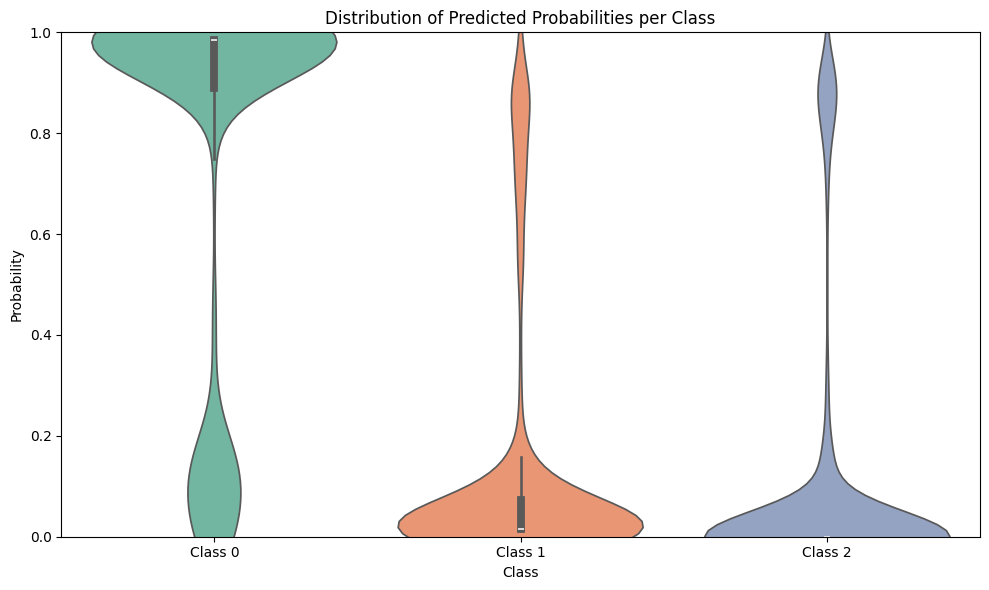

Best thresholds: {0: 0.48484848484848486, 1: 0.393939393939394, 2: 0.0}, Best F1-Score: 0.9971095341706525
Best Macro F1: 0.9971


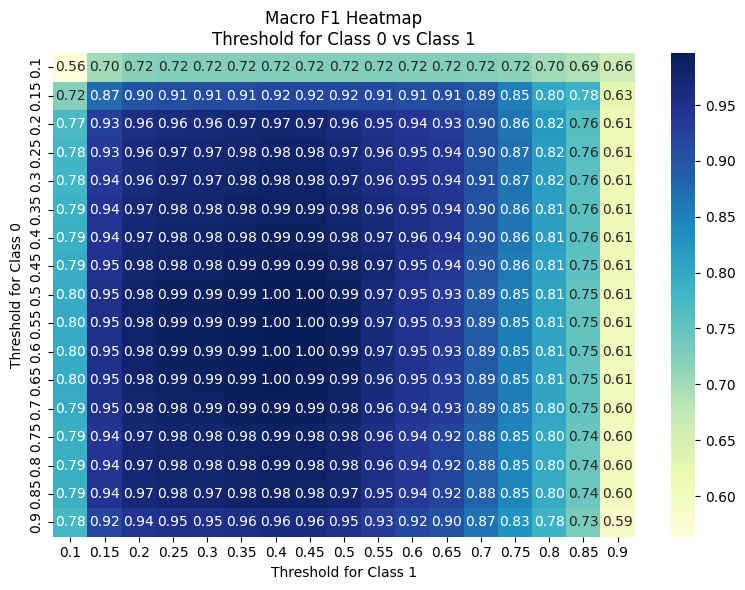

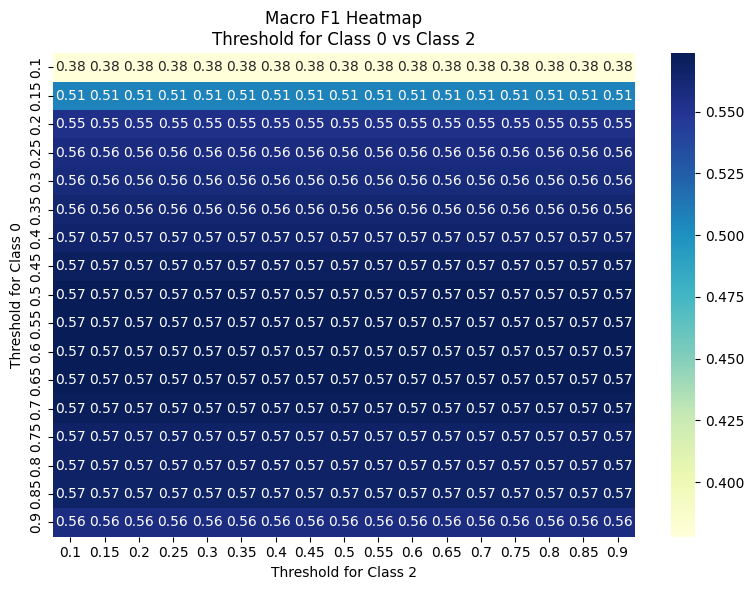

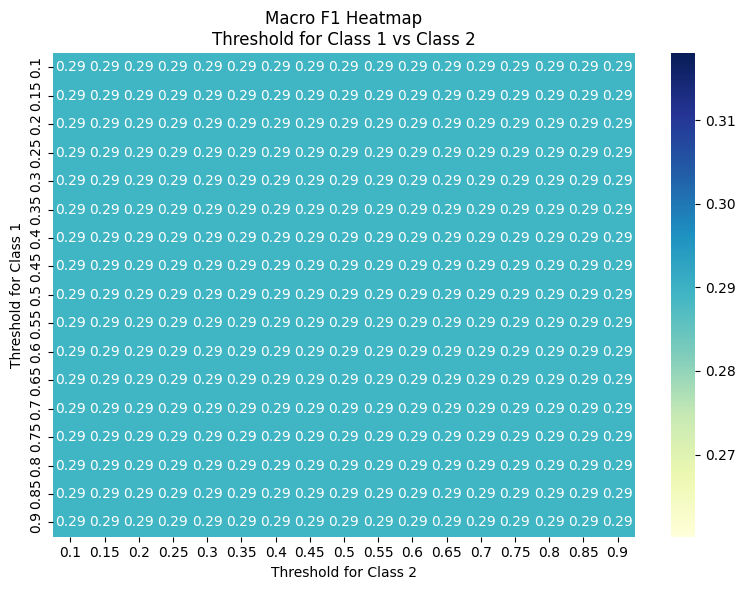

In [358]:
testing(test_result=y_train_1, test_set=X_train_1)

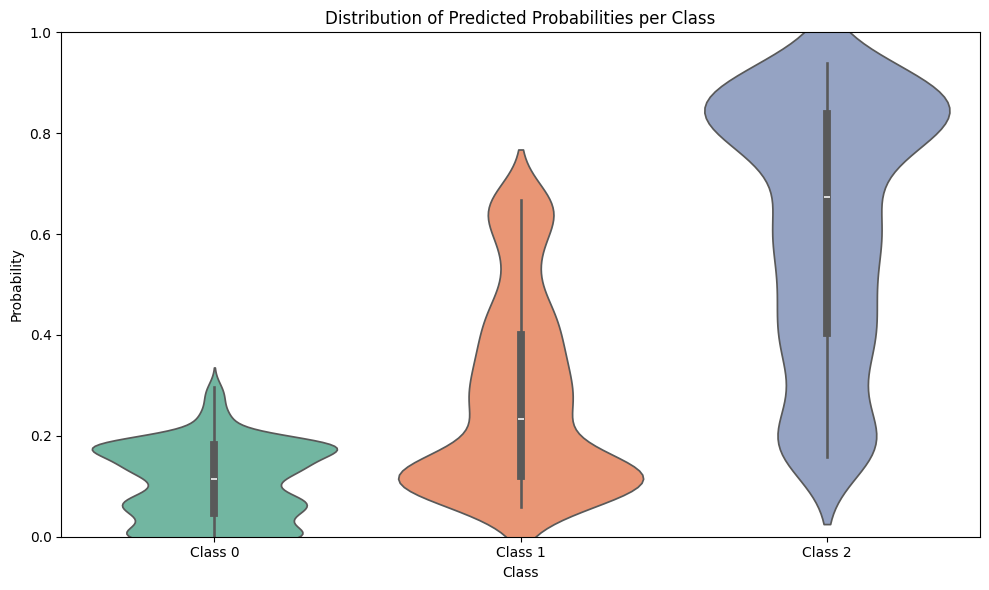

Best thresholds: {0: 0.30303030303030304, 1: 0.23232323232323235, 2: 0.0}, Best F1-Score: 0.8873215448931684
Best Macro F1: 0.8873


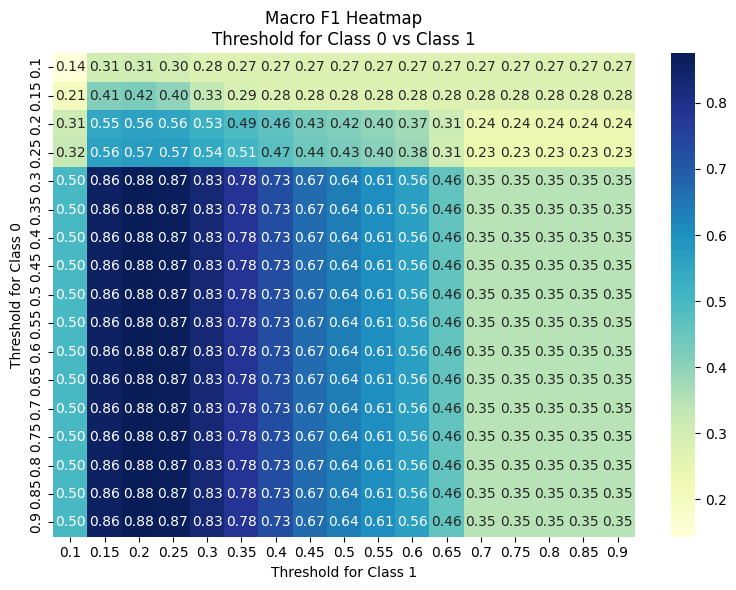

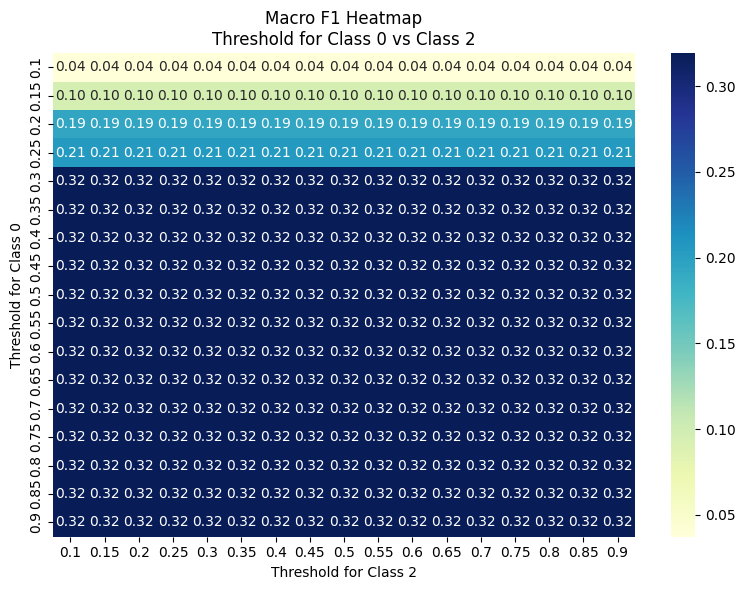

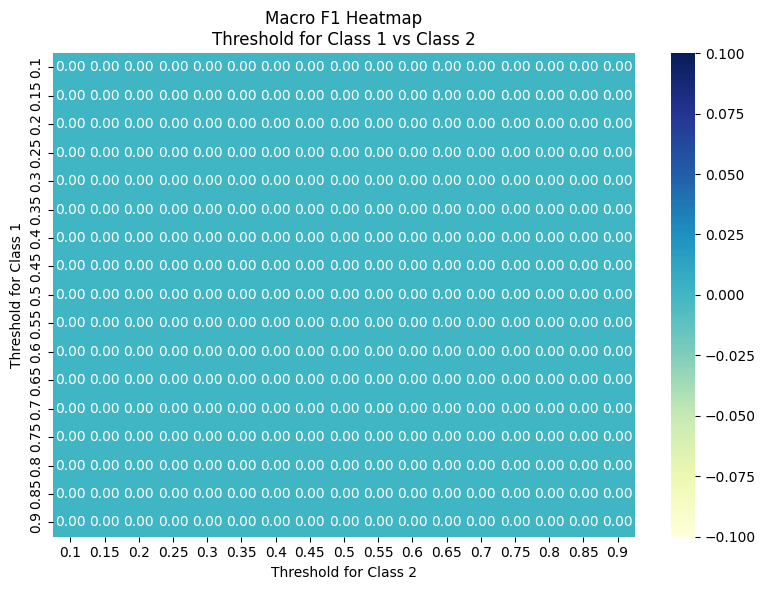

In [359]:
testing(test_result=y_test_1, test_set=X_test_1)

## Test

In [360]:
Evaluation_for_Testing_part(model=tuned_model, threshold={n: t for n, t in zip(range(len(best_threshold)), best_threshold)})

The Best Threshold: {0: 0.7659541126403374, 1: 0.26987128854262094, 2: 0.24545997376568052}
✅ Found all classes starting at index 1823.
⚠️  Skipping fold 1: too few classes in test → {0}
⚠️  Skipping fold 2: too few classes in test → {0}
⚠️  Skipping fold 4: too few classes in test → {0}
[0]	validation_0-mlogloss:1.07405
[100]	validation_0-mlogloss:2.67174
[200]	validation_0-mlogloss:2.70502
[300]	validation_0-mlogloss:2.70056
[314]	validation_0-mlogloss:2.71409

Fold 1
Train: (array([0, 1, 2]), array([458, 458, 458]))
Test: (array([0, 1]), array([62, 57]))
Prediction: (array([0]), array([119])), micro: 0.52, macro: 0.34
[0]	validation_0-mlogloss:1.03291
[100]	validation_0-mlogloss:0.28376
[200]	validation_0-mlogloss:0.25234
[300]	validation_0-mlogloss:0.25327
[314]	validation_0-mlogloss:0.25497

Fold 2
Train: (array([0, 1, 2]), array([422, 422, 422]))
Test: (array([0, 1]), array([99, 20]))
Prediction: (array([0, 1]), array([56, 63])), micro: 0.64, macro: 0.60
[0]	validation_0-mlogloss

# Diagnosis:

In [376]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def diagnostic_report(model, X_train_1, y_train_1, X_test_1, y_test_1, class_names=None):
    
    f1_array_micro = []
    f1_array_macro = []
    valid_folds = 0

    start_index = find_trim_index_to_include_classes(y_train_1.copy().values.ravel(), required_classes=(0, 1, 2), window=600)
    X_subtrain_1, y_subtrain_1 = X_train_1.iloc[start_index:], y_train_1.iloc[start_index:]
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split_with_class_requirements(y_subtrain_1.copy().values.ravel())):
        # Split data
        X_train, y_train = X_subtrain_1.iloc[train_idx].copy(), y_subtrain_1.iloc[train_idx].copy()
        X_test, y_test = X_subtrain_1.iloc[test_idx].copy(), y_subtrain_1.iloc[test_idx].copy()
        
        unit = 3
        if len(np.unique(y_train)) < unit:
            print(f"Skipping fold {fold_idx+1}: insufficient classes -> {np.unique(y_train)}")
            continue
        if len(np.unique(y_test)) < unit-1:
            print(f"Skipping fold {fold_idx+1}: insufficient classes -> {np.unique(y_test)}")
            continue        # Feature selection
        
        X_train = Ensemble_Feature_Selection(model=model, X=X_train, y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]

        # === SMOTE to handle class imbalance in training set ===
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        
        # Count class frequencies
        class_counts = Counter(y_train_res.to_numpy().T[0])
        total = sum(class_counts.values())
        # Compute inverse frequency weight
        class_weights = {cls: total / count for cls, count in class_counts.items()}
        # Apply weight for each sample
        sample_weights = np.array([class_weights[label] for label in y_train_res.to_numpy().T[0]])
        model.fit(
            X_train_res,
            y_train_res,
            sample_weight=sample_weights,
            eval_set=[(X_test, y_test)],
            verbose=100
        )

        y_proba = model.predict_proba(X_test)
        y_pred = predict_with_thresholds_per_class(y_proba, thresholds={n: t for n, t in zip(range(len(best_threshold)), best_threshold)})
        
        # Append scores
        f1_array_micro.append(f1_score(y_true=y_test, y_pred=y_pred, average='micro'))
        f1_array_macro.append(f1_score(y_true=y_test, y_pred=y_pred, average='macro'))
        
        valid_folds += 1
        if valid_folds >= 5:
            break

    X_train_res, y_train_res = X_train_1, y_train_1
    # Count class frequencies
    class_counts = Counter(y_train_res.to_numpy().T[0])
    total = sum(class_counts.values())
    # Compute inverse frequency weight
    class_weights = {cls: total / count for cls, count in class_counts.items()}
    # Apply weight for each sample
    sample_weights = np.array([class_weights[label] for label in y_train_res.to_numpy().T[0]])
    model.fit(
        X_train_res,
        y_train_res,
        sample_weight=sample_weights,
        eval_set=[(X_test_1, y_test_1)],
        verbose=100
    )
    
    # Predict probabilities and labels    
    y_test_proba = model.predict_proba(X_test_1)
    y_test_pred = predict_with_thresholds_per_class(y_test_proba, thresholds={n: t for n, t in zip(range(len(best_threshold)), best_threshold)})

    # Overall F1 scores
    print("📊 === F1 SCORES ===")
    print(f"Micro F1 (train): {np.mean(f1_array_micro):.4f}")
    print(f"Micro F1 (test) : {f1_score(y_test_1, y_test_pred, average='micro'):.4f}")
    print(f"Macro F1 (train): {np.mean(f1_array_macro):.4f}")
    print(f"Macro F1 (test) : {f1_score(y_test_1, y_test_pred, average='macro'):.4f}\n")

    # Per-class F1 report
    print("📋 === PER-CLASS REPORT ===")
    print(classification_report(y_test_1, y_test_pred, target_names=[str(i) for i in np.unique(y_test_1)], digits=4))

    # Class distribution
    unique, counts = np.unique(y_test_1, return_counts=True)
    print("📦 === CLASS DISTRIBUTION (test set) ===")
    for cls, count in zip(unique, counts):
        name = class_names[cls] if class_names else str(cls)
        print(f"Class {name}: {count} samples")

    # Confusion matrix
    print("\n📉 === CONFUSION MATRIX ===")
    cm = confusion_matrix(y_test_1, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in np.unique(y_test_1)])
    disp.plot(cmap="Blues", values_format='d')
    plt.title("Confusion Matrix")
    plt.show()

In [1]:
diagnostic_report(tuned_model, X.copy(), y.copy(), Valid_set.copy(), Valid_result.copy(), class_names=['0', '1', '2'])

NameError: name 'diagnostic_report' is not defined

# Trained-Model Saving:

In [ ]:
import joblib

# Save model and threshold together
package = {
    'model': tuned_model,
    'threshold': best_threshold,
    'feature set': selected_feature_set,
}

joblib.dump(package, '/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Strength/xgb_model_with_threshold.pkl')